# Fourier series/expansion

## Using sympy (symbolic algebra):

We can use the fourier_series() function:
https://docs.sympy.org/latest/modules/series/fourier.html

### Example 1:

Calculate the Fourier expansion of:

$$f(x) = x^2$$

#### Analytical solution:

We consider the Fourier series of $f(x) = x^2$ on the interval $[-\pi, \pi]$.

Since $x^2$ is an even function, its Fourier series contains only cosine terms:

$$f(x) = \frac{a_0}{2} + \sum_{n=1}^{\infty} a_n \cos(nx)$$

**For $a_0$:**

$$a_0 = \frac{1}{\pi} \int_{-\pi}^{\pi} x^2 \, dx = \frac{2}{\pi} \int_{0}^{\pi} x^2 \, dx$$

$$a_0 = \frac{2}{\pi} \cdot \frac{\pi^3}{3} = \frac{2\pi^2}{3}$$

So,

$$\frac{a_0}{2} = \frac{\pi^2}{3}$$

**For $a_n$:**

$$a_n = \frac{1}{\pi} \int_{-\pi}^{\pi} x^2 \cos(nx)\, dx = \frac{2}{\pi} \int_{0}^{\pi} x^2 \cos(nx)\, dx$$

Using integration by parts (twice), the result is:

$$a_n = \frac{4(-1)^n}{n^2}$$

**Fourier Series:**

$$x^2 = \frac{\pi^2}{3} + 4 \sum_{n=1}^{\infty} \frac{(-1)^n}{n^2} \cos(nx)$$

In [1]:
# Importing libraries

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Define symbols
x = sp.symbols('x')

# Function f(x)
y = lambda x: x**2

# Get Fourier series of function
result = sp.fourier_series(x**2, (x, -np.pi, np.pi))

# Same, but using pi from sympy instead of numpy
result1 = sp.fourier_series(x**2, (x, -sp.pi, sp.pi))

# Truncate result to n=3 terms
result_truncated = result.truncate(n=20)
result_truncated1 = result1.truncate(n=20)

# Both show the same result
print(result_truncated)
print()
print(result_truncated1)

-39.4784176043574*cos(0.318309886183791*pi*x)/pi**2 + 9.86960440108936*cos(0.636619772367581*pi*x)/pi**2 - 4.3864908449286*cos(0.954929658551372*pi*x)/pi**2 + 2.46740110027234*cos(1.27323954473516*pi*x)/pi**2 - 1.5791367041743*cos(1.59154943091895*pi*x)/pi**2 + 1.09662271123215*cos(1.90985931710274*pi*x)/pi**2 - 0.805681991925662*cos(2.22816920328654*pi*x)/pi**2 + 0.616850275068085*cos(2.54647908947033*pi*x)/pi**2 - 0.487387871658734*cos(2.86478897565412*pi*x)/pi**2 + 0.394784176043574*cos(3.18309886183791*pi*x)/pi**2 - 0.326267914085599*cos(3.5014087480217*pi*x)/pi**2 + 0.274155677808038*cos(3.81971863420549*pi*x)/pi**2 - 0.233600104167795*cos(4.13802852038928*pi*x)/pi**2 + 0.201420497981415*cos(4.45633840657307*pi*x)/pi**2 - 0.175459633797144*cos(4.77464829275686*pi*x)/pi**2 + 0.154212568767021*cos(5.09295817894065*pi*x)/pi**2 - 0.136603521122344*cos(5.41126806512444*pi*x)/pi**2 + 0.121846967914683*cos(5.72957795130823*pi*x)/pi**2 - 0.109358497518996*cos(6.04788783749202*pi*x)/pi**2 

In [3]:
print(type(result_truncated1))
#print(result_truncated1(x_axis)) # This prints an error

<class 'sympy.core.add.Add'>


### Axes:

In [4]:
# Define the x axis
x_axis = np.arange(-np.pi, np.pi, 0.001)

# We evaluate the y function in our x axis
y_axis = y(x_axis)

# This is wrong
#a = result_truncated1(x_axis)

# This is the correct, this is the way to evaluate a sympy object
y_series = sp.lambdify(x, result_truncated1, "numpy")

print(type(y_series))
y_eval = y_series(x_axis)
#y_eval = result_truncated1(x_axis)
#print(y_eval)

<class 'function'>


### Plotting:

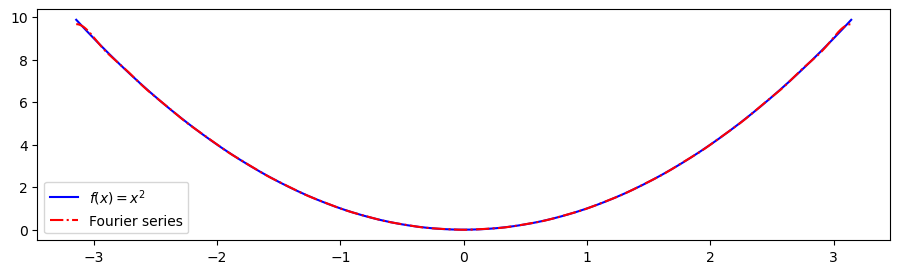

In [5]:
plt.figure(figsize=(11, 3))

plt.plot(x_axis, y_axis, label = r'$f(x)=x^2$', c ='blue')
plt.plot(x_axis, y_eval, label = 'Fourier series', c ='red', linestyle = '-.')

plt.legend()

plt.show()

In [6]:
result2 = sp.fourier_series(x**2, (x, -sp.pi, sp.pi))

result_truncated2 = result2.truncate(n=10)

# This is the correct, this is the way to evaluate a sympy object
y_series2 = sp.lambdify(x, result_truncated2, "numpy")

# Evaluate in x axis
y_eval2 = y_series2(x_axis)

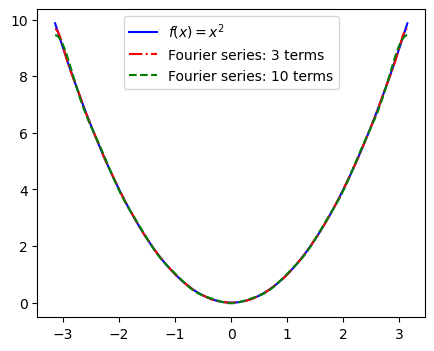

In [7]:
plt.figure(figsize=(5, 4))

plt.plot(x_axis, y_axis, label = r'$f(x)=x^2$', c ='blue')
plt.plot(x_axis, y_eval, label = 'Fourier series: 3 terms', c ='red', linestyle = '-.')
plt.plot(x_axis, y_eval2, label = 'Fourier series: 10 terms', c ='green', linestyle = '--')

plt.legend()

plt.show()

## Example 2:

Calculate the Fourier expansion of:

$f(x) = 
\left\{
    \begin{array}{lr}
        0, & -\pi \leq x \leq -\frac{\pi}{2}\\
        1, & -\frac{\pi}{2} \leq x \leq +\frac{\pi}{2}\\
        0, & +\frac{\pi}{2} \leq x \leq +\pi
    \end{array}
\right\}$


#### Analytical Solution:

We compute the Fourier series on $[-\pi,\pi]$:

$$f(x) = \frac{a_0}{2} + \sum_{n=1}^{\infty} \left(a_n \cos(nx) + b_n \sin(nx)\right)$$

**Symmetry Analysis:**

The function is even, so:

$$b_n = 0$$

Thus,

$$f(x) = \frac{a_0}{2} + \sum_{n=1}^{\infty} a_n \cos(nx)$$


**For $a_0$:**

$$a_0 = \frac{1}{\pi} \int_{-\pi}^{\pi} f(x)\,dx = \frac{2}{\pi} \int_{0}^{\pi/2} 1 \, dx$$

$$a_0 = \frac{2}{\pi} \cdot \frac{\pi}{2} = 1$$

So,

$$\frac{a_0}{2} = \frac{1}{2}$$

**For $a_n$:**

$$a_n = \frac{1}{\pi} \int_{-\pi}^{\pi} f(x)\cos(nx)\,dx= \frac{2}{\pi} \int_{0}^{\pi/2} \cos(nx)\,dx$$

$$a_n = \frac{2}{\pi} \left[ \frac{\sin(nx)}{n} \right]_{0}^{\pi/2}= \frac{2}{\pi} \cdot \frac{\sin\left(\frac{n\pi}{2}\right)}{n}$$


**Fourier Series:**

$$f(x) = \frac{1}{2} + \frac{2}{\pi} \sum_{n=1}^{\infty} \frac{\sin\left(\frac{n\pi}{2}\right)}{n} \cos(nx)$$

In [8]:
def function(x):
    """
    This is a piece-wise function for the top-hat function showsn above.
    """
    
    if(-np.pi <= x <= -0.5*np.pi):
        return 0

    elif(-0.5*np.pi <= x <= +0.5*np.pi):
        return 1
    
    else:
        return 0

### Define axes:

In [9]:
# X vector
x = np.arange(-np.pi, np.pi, 0.001)

# This is wrong:
#yy = function(x)

In [10]:
# Empty list (needed)
y = []

# Loop to append the evaluated points
for i in range(len(x)):
    y.append(function(x[i]))

# Convert to an array
y = np.array(y)

In [11]:
print(x.size, y.size)

6284 6284


### Plotting:


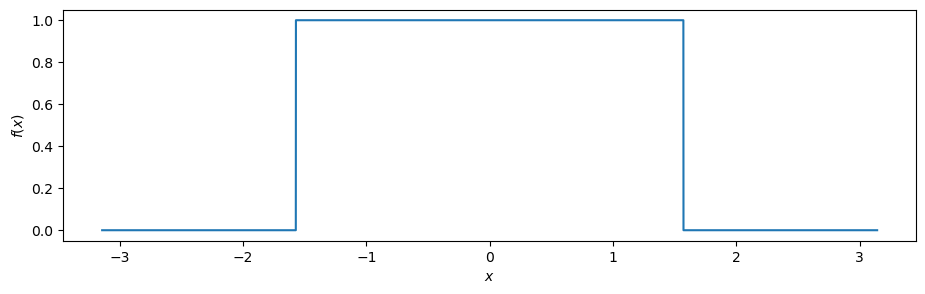

In [12]:
plt.figure(figsize=(11, 3))

plt.plot(x, y)

plt.xlabel(r"$x$")
plt.ylabel(r"$f(x)$")

plt.show()

https://en.wikipedia.org/wiki/Fourier_series

In [13]:
def function_Fourier(x, n):
    """
    This is a function to calculate the Fourier expansion.
    Inputs: x -> vector for the domain
            n -> the trunction integer
    """
    
    # Empty array
    f = np.zeros(x.size)

    # Add the first term
    f = f + 0.5

    for i in range(1,n+1):
        #print(i)
        y = (2/np.pi)*((-1)**(i-1))*(1/(2*i-1))*np.cos((2*i - 1)*x)

        # Adding the next Fourier terms
        f += y 
        
    return f

## Plotting

In [14]:
# Evaluate our Fourier series

fourier_1 = function_Fourier(x, 1)
fourier_2 = function_Fourier(x, 2)
fourier_10 = function_Fourier(x, 10)
fourier_50 = function_Fourier(x, 50)

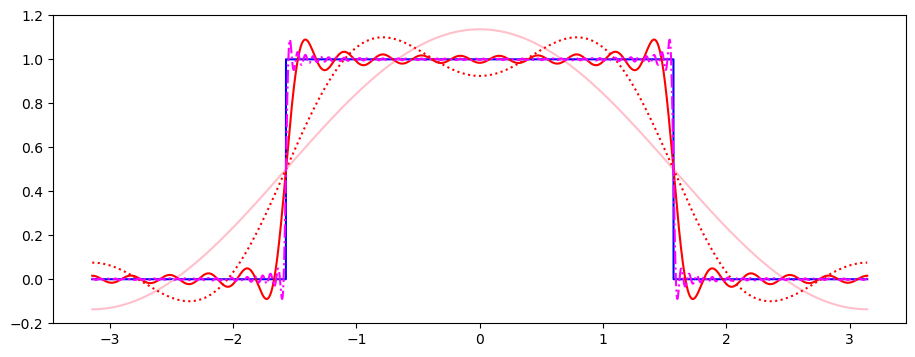

In [15]:
plt.figure(figsize=(11, 4))

plt.plot(x, y, c ='blue')
plt.plot(x, fourier_1, c = 'pink')
plt.plot(x, fourier_2, c = 'red', linestyle =':')
plt.plot(x, fourier_10, c = 'red', linestyle ='-')
plt.plot(x, fourier_50, c = 'magenta', linestyle ='-.')

plt.show()

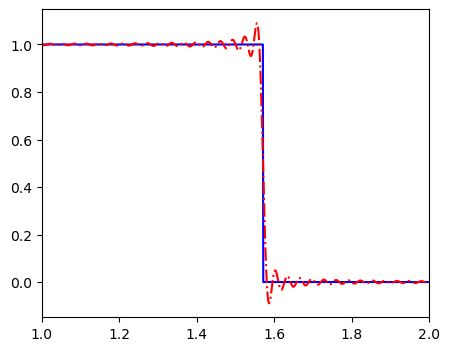

In [16]:
plt.figure(figsize=(5, 4))

plt.plot(x, y, c ='blue')
#plt.plot(x, function_Fourier(x, 1), c = 'red')
#plt.plot(x, function_Fourier(x, 2), c = 'red', linestyle =':')
plt.plot(x, function_Fourier(x, 100), c = 'red', linestyle ='-.')

plt.xlim(1,2)

plt.show()

## Piece-wise function using sympy:

In [17]:
# Define the symbol
xx = sp.Symbol('x')

# Define the piece wise function
phi_1 = sp.Piecewise((0, xx < -sp.pi/2), (0, xx > +sp.pi/2), (1, True))

print(type(phi_1))

# This is converting our sympy object into a numpy one
y_func = sp.lambdify(xx, phi_1, "numpy")

# Evaluate the function using the x vector
y_axis = y_func(x_axis)

print(type(y_func))

Piecewise
<class 'function'>


## Fourier series of piece-wise function:

In [18]:
# Getting the Fourier series
y_fourier = sp.fourier_series(phi_1, (xx, -sp.pi, sp.pi))

# We truncate it
y_fouriertruncated1 = y_fourier.truncate(n=10)

print(y_fouriertruncated1)
#print(type(y_fouriertruncated1))

# This is converting our sympy object for thr Fourier expansion into a numpy one
y_func2 = sp.lambdify(xx, y_fouriertruncated1, "numpy")

# Evaluate the function using the x vector
y_axis2 = y_func2(x_axis)

2*cos(x)/pi - 2*cos(3*x)/(3*pi) + 2*cos(5*x)/(5*pi) - 2*cos(7*x)/(7*pi) + 2*cos(9*x)/(9*pi) - 2*cos(11*x)/(11*pi) + 2*cos(13*x)/(13*pi) - 2*cos(15*x)/(15*pi) + 2*cos(17*x)/(17*pi) + 1/2


## Plotting:

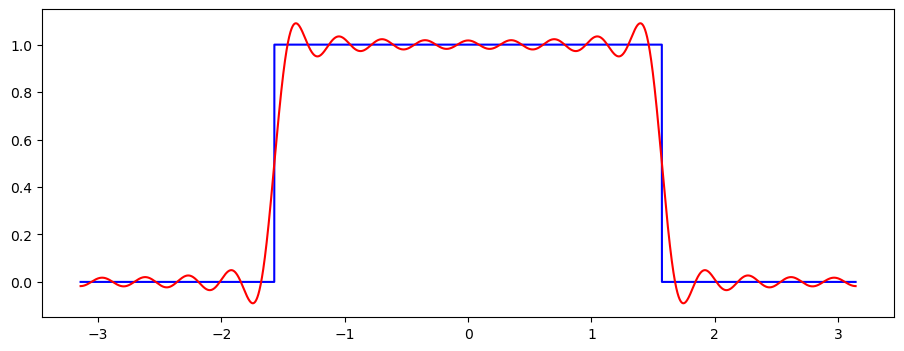

In [19]:
plt.figure(figsize=(11, 4))

plt.plot(x_axis, y_axis, c ='blue')
plt.plot(x_axis, y_axis2, c ='red')

plt.show()

## Using Riemann sums for the integral definitions:

In [20]:
# This method is expensive:
def c0():
    c_0 = y_axis
    return c_0.sum()/c_0.size

def cn(n):
    c = y_axis*np.exp(-1j*2*n*np.pi*x_axis/period)
    return c.sum()/c.size

def f(x_axis, Nh):
    f = np.array([2*cn(i)*np.exp(1j*2*i*np.pi*x_axis/period) for i in range(1,Nh+1)])
    return c0() + f.sum()

In [21]:
period = 2*np.pi

print(c0())

x_axis = np.arange(-np.pi, np.pi, 0.001)

y_riemann = np.array([f(t,100).real for t in x_axis])

0.5


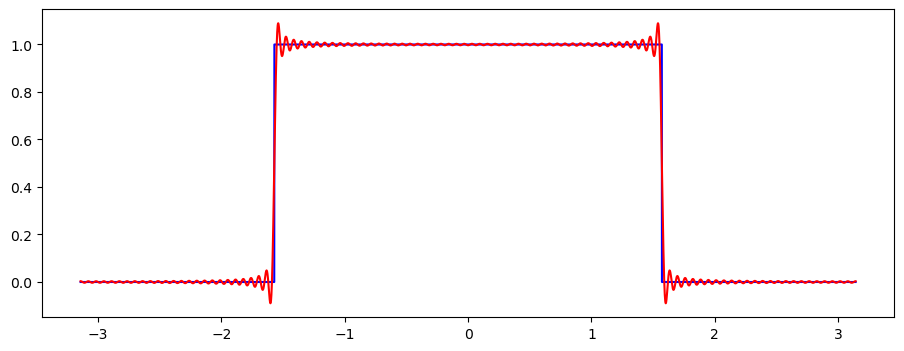

In [22]:
plt.figure(figsize=(11, 4))
plt.plot(x_axis, y_axis, c ='blue')
plt.plot(x_axis, y_riemann, c ='red')
plt.show()